## 1. Установка зависимостей

In [1]:
!pip install transformers 

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.2 MB 3.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/10.2 MB 6.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/10.2 MB 6.7 MB/s eta 0:00:02
   --------------------- ------------------ 5.5/10.2 MB 7.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.6/10.2 MB 7.7 MB/s eta 0:00:01
   ------------------------------------- -- 9.7/10.2 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 8.0 MB/s  0:00:01
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

   ---------- ----------------------------- 

## 2. Определение TrOCRRecognizer

Согласно API Pipeline, распознаватель должен реализовать метод `predict`, который:
- Принимает: `List[np.ndarray]` — список изображений слов (RGB)
- Возвращает: `List[Dict[str, Any]]` — список словарей с ключами `"text"` и `"confidence"`

In [1]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

from manuscript.data import Page
from manuscript.utils import collapse_page_text_spans, crop_axis_aligned, read_image


class TrOCRRecognizer:
    def __init__(
        self,
        model_name: str = "taiga75/ru-trocr-1700s",
        device: Optional[str] = None,
        batch_size: int = 8,
    ):
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name).to(self.device).eval()

    @staticmethod
    def _to_pil(img):
        if isinstance(img, Image.Image):
            return img.convert("RGB")

        img = np.asarray(img)
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]

        return Image.fromarray(img.astype(np.uint8)).convert("RGB")

    @staticmethod
    def _crop(image, polygon):
        return crop_axis_aligned(image, polygon)

    def predict(
        self,
        page: Page,
        image: Optional[Union[str, Path, np.ndarray, Image.Image]] = None,
        batch_size: Optional[int] = None,
    ) -> Page:
        if image is None:
            return page.model_copy(deep=True)

        image = read_image(image)

        # Схлопываем все text span внутри каждой строки в один общий span
        result_page = collapse_page_text_spans(
            page,
            level="line",
            method="convex_hull",
        )

        spans = []
        crops = []

        for block in result_page.blocks:
            for line in block.lines:
                if not line.text_spans:
                    continue

                span = line.text_spans[0]
                crop = self._crop(image, span.polygon)
                if crop is None or crop.size == 0:
                    continue

                spans.append(span)
                crops.append(self._to_pil(crop))

        if not crops:
            return result_page

        step = batch_size or self.batch_size

        for i in range(0, len(crops), step):
            batch = crops[i:i + step]
            pixel_values = self.processor(images=batch, return_tensors="pt").pixel_values.to(self.device)

            with torch.no_grad():
                tokens = self.model.generate(pixel_values)

            texts = self.processor.batch_decode(tokens, skip_special_tokens=True)

            for span, text in zip(spans[i:i + step], texts):
                span.text = text.strip()
                span.recognition_confidence = 1.0

        return result_page

c:\Users\USER\manuscript-ocr-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Пример использования с детектором EAST (по умолчанию)

Используем встроенный детектор EAST и наш TrOCR распознаватель.

Loading weights: 100%|██████████| 480/480 [00:00<00:00, 13714.35it/s]


[YOLO] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
Распознанный текст:
%,
Суходство.
26.
Способныя къ оброхвоству раки въ губер-
нш: Енисей, Туба, Оя, Ангара или
Верхняя Тунауска, Кеть, Усолка и Чу-
лымъ.
Главнѣйшая пристань въ суверни
находится въ г. Енисейскi, куха сплав-
ляется хлюбъ и Фрарце предметы для
болотыхъ промысловъ, Туруханскаго края
и жителей г. Енисейски,
Въ новигацию 1868 года пароходъ Енисей,
въ 60 силъ съ 2- баросами совершилъ отъ
г. Енисельска въ Турфханскiй край обинъ
решь и воходилъ 90 Малобреховскихъ
и Охотскихъ острововъ, отстоящихъ
отъ г. Енисейска на 2020 версть. Въ
Туруланский край отправлено хлюба,
жизненныхъ припасовъ и равныхъ това-
ровь на 2200р., а оттуда приведено:
8500 пїр. равней рыбы на 1299р. 52; и
руинаго товару и Малеонтовой кости
на 103919. 444 к. всего на 2279ор. Ящ к

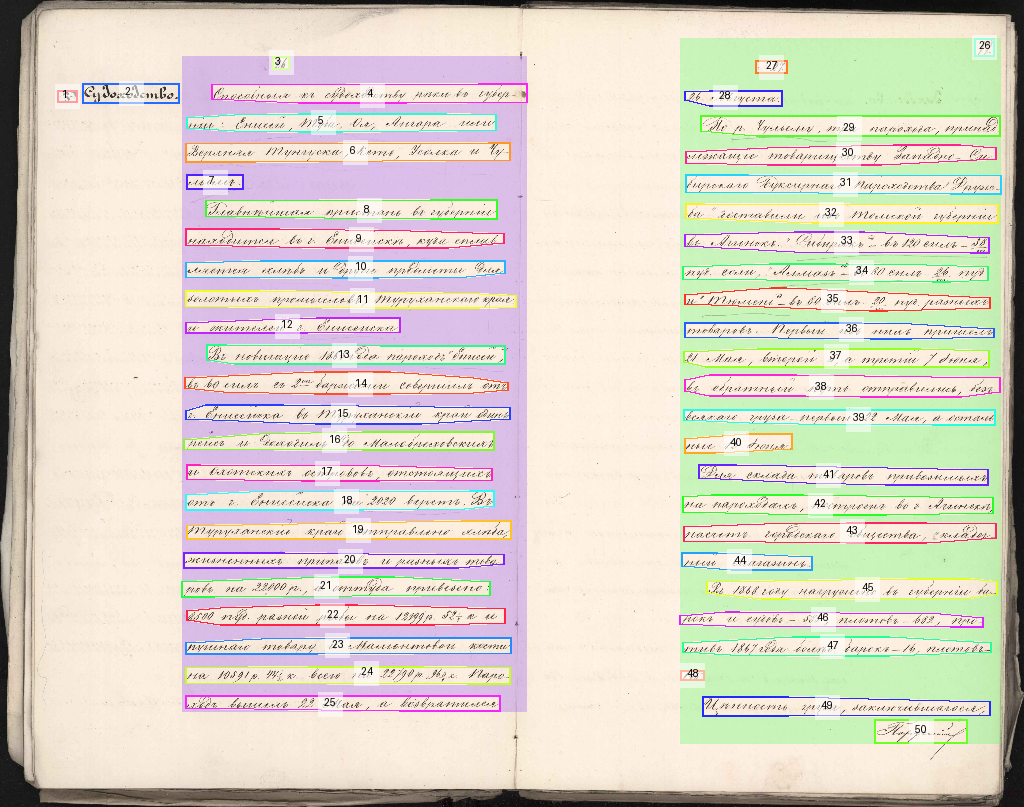

In [2]:
from manuscript import Pipeline
from manuscript.utils import visualize_page

image_path = r"C:\Users\USER\manuscript-ocr-2\example\ocr_example_image.jpg"

trocr_recognizer = TrOCRRecognizer(
    model_name="taiga75/ru-trocr-1700s",
    batch_size=1,
)

pipeline = Pipeline(
    recognizer=trocr_recognizer,
)

result = pipeline.predict(image_path)
page = result["page"]

print("=" * 50)
print("Распознанный текст:")
print("=" * 50)
print(pipeline.get_text(page))

visualize_page(
    image_path,
    page,
    show_lines=False,
    show_numbers=True,
    max_size=1024,
)
